<a href="https://colab.research.google.com/github/mjawadiqbal5-jpg/Diamond-Price-Predictions/blob/main/Diamonds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Diamond price predictions againt actual price and features affecting diamond price using XGBoost algorithm for analysis**

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

In [85]:
# --- 1. STARTING THE PROJECT & LOADING DATA ---
# Load the diamond dataset
df = pd.read_csv("diamonds.csv")

# display rows and shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"\nClass distribution (target: price):")
print(df['price'].value_counts())

# Display dataset
df

Rows: 53940
Columns: 11

Class distribution (target: price):
price
605     132
802     127
625     126
828     125
776     124
       ... 
2769      1
9033      1
9027      1
9026      1
9025      1
Name: count, Length: 11602, dtype: int64


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [86]:
# --- 2. DATA CLEANING & IMPUTING ---
# Fill missing numerical values with column mean
df = df.fillna(df.mean(numeric_only=True))

# Define the order from lowest quality to highest quality
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_order = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_order = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

# Apply the mapping
df['cut'] = df['cut'].map(cut_order)
df['color'] = df['color'].map(color_order)
df['clarity'] = df['clarity'].map(clarity_order)

# Display the verification report
print("--- Transformation Verification ---")
for col in ['cut', 'color', 'clarity']:
    print(f"Encoded column: '{col}' | New unique values: {sorted(df[col].unique())}")

# display dataset to check
df

--- Transformation Verification ---
Encoded column: 'cut' | New unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Encoded column: 'color' | New unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Encoded column: 'clarity' | New unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,4,5,1,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,3,5,2,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,1,5,4,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,3,1,3,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,1,0,1,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,4,6,2,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,1,6,2,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,2,6,2,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,3,2,1,61.0,58.0,2757,6.15,6.12,3.74


In [87]:
# --- 3. FEATURE EXTRACTION & LOG TRANSFORMATION ---
# Drop 'price' to create the features, and drop 'Unnamed: 0' if it exists
X = df.drop(['price'], axis=1)
if 'Unnamed: 0' in X.columns:
    X = X.drop(['Unnamed: 0'], axis=1)

# Log Transformation of target to handle price skewness
y_log = np.log1p(df['price'])

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y_log.shape}")
print(f"Features used: {list(X.columns)}")

Feature matrix shape: (53940, 9)
Target vector shape:  (53940,)
Features used: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']


In [88]:
# --- 4. TRAINING AND TESTING DATA ---
# Split dataset into training (70%) and testing (30%)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.3, random_state=42
)

print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Test set size:      {X_test.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train_log.value_counts()}")
print(f"\nTest class distribution:\n{y_test_log.value_counts()}")

Training set size:  37758 samples
Test set size:      16182 samples

Training class distribution:
price
6.406880    98
6.549651    92
6.300786    87
6.720220    86
6.672033    85
            ..
8.756525     1
9.350015     1
9.780924     1
7.861727     1
8.850231     1
Name: count, Length: 10157, dtype: int64

Test class distribution:
price
6.688355    48
6.655440    42
6.439350    41
6.720220    39
6.739337    38
            ..
9.518340     1
8.262043     1
8.108322     1
9.193601     1
7.993958     1
Name: count, Length: 6748, dtype: int64


In [89]:
# --- 5. HYPERPARAMETER TUNING ---
# Define the search space
param_grid = {
    'n_estimators': [100, 500, 800],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42)

# Set up Random Search (tries 10 random combinations)
tuned_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Train RandomizedSearchCV on the training data
tuned_search.fit(X_train, y_train_log)

# Store the best model
best_model = tuned_search.best_estimator_

# Show best parameters
print("Best Parameters:", tuned_search.best_params_)
print(f"\nBest cross-validated neg_mean_absolute_error: {tuned_search.best_score_:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.8}

Best cross-validated neg_mean_absolute_error: -0.0617


In [90]:
# --- 6. MODEL FITTING & EVALUATION ---
# 1. # Converting log predictions back to regular values
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

# 2. Calculate Regression Metrics
mae = mean_absolute_error(y_test, y_pred) # Average dollar error
r2 = r2_score(y_test, y_pred)             # How well the model fits the data

# 3. Print performance results
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R² Score: {r2:.4f}")

# Optional: Show the first 5 actual vs predicted prices
results_comparison = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
print("\nSample Predictions:")
print(results_comparison.head())

Mean Absolute Error (MAE): $259.43
R² Score: 0.9825

Sample Predictions:
       Actual Price  Predicted Price
1388          559.0       558.170105
50052        2201.0      2285.111572
41645        1238.0      1250.270386
42377        1304.0      1291.532959
17244        6901.0      9044.058594


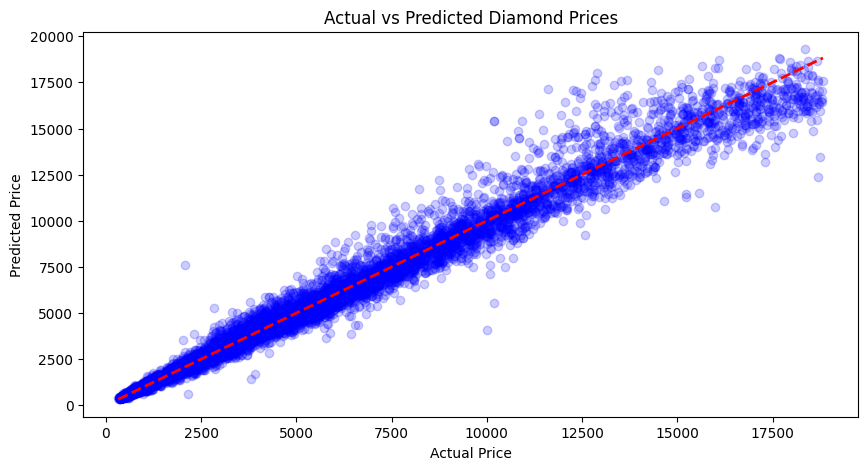

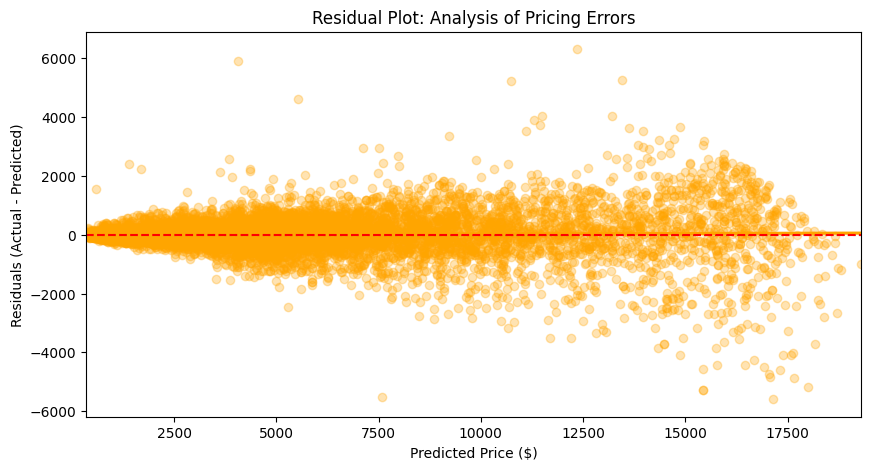

In [93]:
# --- 7. PRELIMINARY DATA ANALYSIS & VISUALISATION ---
# Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.2, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Diamond Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

# Residual Plot (Error Analysis)
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
sns.residplot(x=y_pred, y=residuals, lowess=True, color="orange", scatter_kws={'alpha': 0.3})
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot: Analysis of Pricing Errors')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

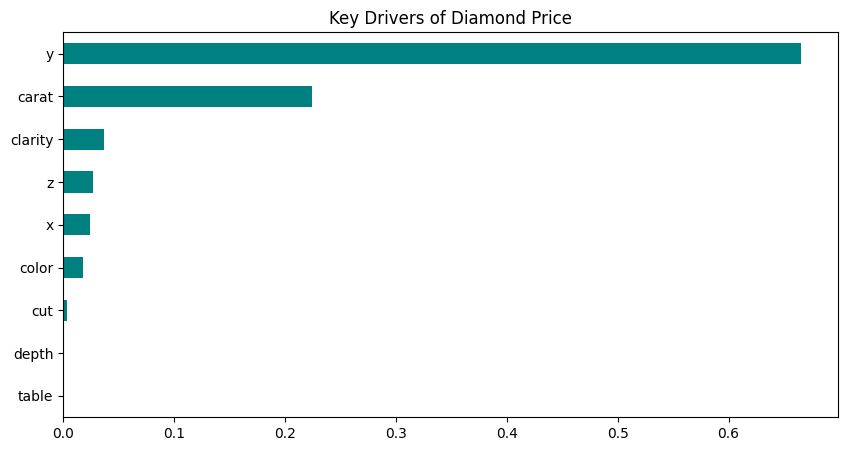

In [94]:
# Feature Importance
plt.figure(figsize=(10, 5))
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Key Drivers of Diamond Price')
plt.show()

In [95]:
# --- 8. MODEL PERSISTENCE ---
# Saving the model for later use
joblib.dump(best_model, 'diamond_price_model.pkl')
print("\n✅ Model saved successfully as 'diamond_price_model.pkl'")


✅ Model saved successfully as 'diamond_price_model.pkl'
